In [2]:
import json
import numpy as np
import plotly.express as px

topology = json.load(open("layouts/double_line_64_interfaces_twoside.json", "r"))
floorplan = np.zeros((topology["n"], topology["m"]))
for i, j in topology["unavailable_locations"]:
    floorplan[i][j] = -1
for i, j in topology["interface_locations"]:
    floorplan[i][j] = 1
px.imshow(floorplan, color_continuous_scale=["black", "lightgray", "green"])

# print all available 
# print("Available locations:")
# counter = 0
# for i in range(topology["n"]):
#     for j in range(topology["m"]):
#         if floorplan[i][j] == 0 or floorplan[i][j] == 1:
#             # print(f"[{i}, {j}], ", end="")
#             counter+=1
# print(counter)

In [38]:
# LINE - 0,1 0,2 ... 0,n
n  = 64
all_possible_locs = [(i, 0) for i in range(n)]
jsonn = {
    "n": n,
    "m": 1,
    "unavailable_locations": [],
    "interface_locations": list(set(all_possible_locs))
}
json.dump(jsonn, open("layouts/line_64.json", "w"))

In [3]:
# DOUBLE LINE 

tiles = 64
assert tiles % 2 == 0
n = int(tiles/2)

all_possible_locs = []
for i in range(n):
    all_possible_locs.append((i, 0))
    all_possible_locs.append((i, 1))
jsonn = {
    "n": n,
    "m": 2,
    "unavailable_locations": [],
    "interface_locations": list(set(all_possible_locs))
}
json.dump(jsonn, open("layouts/double_line_64.json", "w"))

In [185]:
import numpy as np
import plotly.express as px

# Configuration
n, m = 10, 8  # Grid size
num_squares = 14  # Total squares
size_column_x = 1
size_column_y = 1
margin_x = 1
margin_y = 1

unavailable_locations = [
# left top
(3, 1),
(3, 2),
(2, 2),
(2, 1),

# right top 
(7, 1),
(7, 2),
(6, 1),
(6, 2),


 (2, 5),
 (3, 5),
 (2, 6),
 (3, 6),

# down right
 (6, 5),
 (6, 6),
 (7, 5),
 (7, 6)]
all_available_locs = [
    (i, j) for i in range(n) for j in range(m)
    if (i, j) not in unavailable_locations
]
frame_positions = []
for i in range(n):
    frame_positions.append((i, 0))
    frame_positions.append((i, m - 1))
for i in range(m):
    frame_positions.append((0, i))
    frame_positions.append((n - 1,i))
oneside_positions = []
for i in range(m):
    oneside_positions.append((0, i))

# Final JSON structure
jsonn = {
    "n": n,
    "m": m,
    "unavailable_locations": unavailable_locations,
    "interface_locations": list(set(oneside_positions))
}

# Visualization
print('unavailable_locations:', len(unavailable_locations), 
      'available_locations:', n * m - len(unavailable_locations))
floorplan = np.zeros((n, m))
for i, j in jsonn["unavailable_locations"]:
    floorplan[i][j] = -1
for i, j in jsonn["interface_locations"]:
    floorplan[i][j] = 1


json.dump(jsonn, open("layouts/columns_64_interfaces_oneside.json", "w"))

px.imshow(floorplan, color_continuous_scale=["black", "lightgray", "yellow"])

# jsonn["unavailable_locations"]

unavailable_locations: 16 available_locations: 64


In [13]:
def create_h_layout_unavailable(n, m, num_available, bar_width=1):
    if bar_width * 2 > m:
        raise ValueError("Bar width too large for the grid width.")
    h_positions = set()

    # Left and right bar columns
    left_cols = range(0, bar_width)
    right_cols = range(m - bar_width, m)

    # Add vertical bars
    for row in range(n):
        for col in left_cols:
            h_positions.add((row, col))
        for col in right_cols:
            h_positions.add((row, col))

    # Add middle horizontal bar
    middle_row = n // 2
    for col in range(m):
        h_positions.add((middle_row, col))

    # Trim if needed
    h_positions = list(h_positions)
    if len(h_positions) > num_available:
        h_positions = h_positions[:num_available]
    elif len(h_positions) < num_available:
        raise ValueError("Requested more available positions than the H shape can provide.")

    available_set = set(h_positions)
    unavailable_positions = [
        (i, j) for i in range(n) for j in range(m) if (i, j) not in available_set
    ]

    return n, m, unavailable_positions, available_set

# n, m, unavailable, available_set = create_h_layout_unavailable(5, 16, 64, 6) # 64
n, m, unavailable, available_set = create_h_layout_unavailable(5, 12, 44, 4)
# n, m, unavailable = create_h_layout_unavailable(8, 7, 49, 3)
frame_positions = []
for i in range(n):
    if (i, 0) not in unavailable:
        frame_positions.append((i, 0))
    if (i, m - 1) not in unavailable:
        frame_positions.append((i, m - 1))
for i in range(m):
    if (0, i) not in unavailable:
        frame_positions.append((0, i))
    if (n - 1, i) not in unavailable:
        frame_positions.append((n - 1,i))

jsonn = {
    "n": n,
    "m": m,
    "unavailable_locations": unavailable,
    "interface_locations": list(available_set), #list(set(frame_positions))
}


json.dump(jsonn, open("layouts/layout_H_formed_44_interfaces_anywhere.json", "w"))

print('unavailable_locations', len(unavailable), 'available_locations', n*m-len(unavailable))
floorplan = np.zeros((jsonn["n"], jsonn["m"]))
for i, j in jsonn["unavailable_locations"]:
    floorplan[i][j] = -1
for i, j in jsonn["interface_locations"]:
    floorplan[i][j] = 1
px.imshow(floorplan, color_continuous_scale=["black", "lightgray", "green"])

unavailable_locations 16 available_locations 44


In [ ]:
# H formed
n = 8 
m = 7
unavailable_locations = []
all_available_locs = []
for i in range(n):
    for j in range(m):
        if (i, j) not in unavailable_locations:
            all_available_locs.append((i, j))



jsonn = {
    "n": n,
    "m": m,
    "unavailable_locations": unavailable_locations,
    "interface_locations": list(set(all_available_locs))
}
print('unavailable_locations', len(unavailable_locations), 'available_locations', n*m-len(unavailable_locations))

floorplan = np.zeros((jsonn["n"], jsonn["m"]))
for i, j in jsonn["unavailable_locations"]:
    floorplan[i][j] = -1
for i, j in jsonn["interface_locations"]:
    floorplan[i][j] = 1
px.imshow(floorplan, color_continuous_scale=["black", "lightgray", "green"])

unavailable_locations 0 available_locations 56


In [23]:
# SQUARE, RECTANGLE nxm
n = 7
m = 7
all_locations = []
unavailable_locations = []
for i in range(n):
    for j in range(m):
        all_locations.append((i, j))

frame_positions = []
for i in range(n):
    frame_positions.append((i, 0))
    frame_positions.append((i, m - 1))
for i in range(m):
    frame_positions.append((0, i))
    frame_positions.append((n - 1,i))

one_side_positions = []
for i in range(m):
    one_side_positions.append((n-1, i))

jsonn = {
    "n": n,
    "m": m,
    "unavailable_locations": unavailable_locations,
    "interface_locations": list(set(one_side_positions))
}
json.dump(jsonn, open("layouts/layout_square_49_interfaces_one_side.json", "w"))

In [39]:
# RING
number_tiles_and_interface = 64
assert number_tiles_and_interface % 2 == 0, "Number of tiles and interface locations must be even for ring layout"

def get_rectangle_sizes_from_edge_cells(edge_cells):
    best_size = None
    min_diff = float('inf')

    for width in range(1, edge_cells + 1):
        remainder = edge_cells + 4 - 2 * width
        if remainder % 2 != 0:
            continue
        height = remainder // 2
        if height >= 1:
            diff = abs(width - height)
            if diff < min_diff:
                min_diff = diff
                best_size = (width, height)
    return best_size

n, m = get_rectangle_sizes_from_edge_cells(number_tiles_and_interface)
print(f"n = {n}, m = {m}")

all_positions = []
for i in range(n):
    for j in range(m):
        all_positions.append((i, j))

# if x=0 or y =0 or x = n-1 or y = m-1, then it is a frame
frame_positions = []
for i in range(n):
    frame_positions.append((i, 0))
    frame_positions.append((i, m - 1))
for j in range(m):
    frame_positions.append((0, j))
    frame_positions.append((n - 1, j))

all_but_frame = list(set(all_positions) - set(frame_positions))
jsonn = {
    "n": n,
    "m": m,
    "unavailable_locations": all_but_frame,
    "interface_locations": list(set(frame_positions))
}
assert len(set(frame_positions)) == number_tiles_and_interface, f"Number of locations {len(set(frame_positions))} is not equal to expected {number_tiles_and_interface}"
json.dump(jsonn, open("layout_ring_64.json", "w"))

n = 17, m = 17


In [4]:
def get_frame_positions(): 
    # 0,0 ; 0,1 ... 0,topology['n']-1 etc
    return [(i, j) for i in range(topology["n"]) for j in range(topology["m"])]

In [5]:
get_frame_positions()

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (3, 5),
 (3, 6),
 (3, 7),
 (3, 8),
 (3, 9),
 (3, 10),
 (3, 11),
 (3, 12),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4),
 (4, 5),
 (4, 6),
 (4, 7),
 (4, 8),
 (4, 9),
 (4, 10),
 (4, 11),
 (4, 12),
 (5, 0),
 (5, 1),
 (5, 2),
 (5, 3),
 (5, 4),
 (5, 5),
 (5, 6),
 (5, 7),
 (5, 8),
 (5, 9),
 (5, 10),
 (5, 11),
 (5, 12),
 (6, 0),
 (6, 1),
 (6, 2),
 (6, 3),
 (6, 4),
 (6, 5),
 (6, 6),
 (6, 7),
 (6, 8),
 (6, 9),
 (6, 10),
 (6, 11),
 (6, 12),
 (7, 0),
 (7, 1),
 (7, 2),
 (7, 3),
 (7, 4),
 (7, 5),
 (7, 6),
 (7, 7),
 (7, 8),
 (7, 9),
 (7, 10),
 (7, 11),
 (7, 12),
 (8, 0),
 (8, 1),
 (8, 2),
 (8, 3),
 (8,

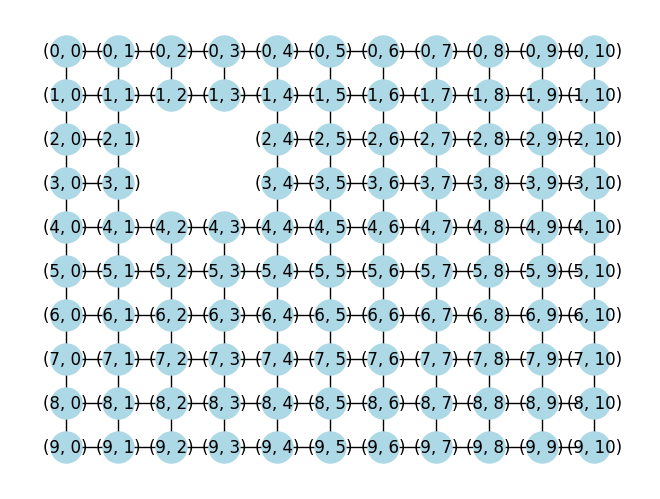

In [2]:
import networkx as nx

def create_grid_graph(n, m, unavailable_nodes):
    G = nx.Graph()
    
    # Add nodes (only available positions)
    for i in range(n):
        for j in range(m):
            if (i, j) not in unavailable_nodes:
                G.add_node((i, j))

    # Add edges between adjacent available nodes
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # Up, Down, Left, Right
    
    for i in range(n):
        for j in range(m):
            if (i, j) not in unavailable_nodes:
                for di, dj in directions:
                    ni, nj = i + di, j + dj
                    if 0 <= ni < n and 0 <= nj < m and (ni, nj) not in unavailable_nodes:
                        G.add_edge((i, j), (ni, nj))

    return G

# Example Usage
n, m = 10, 11  # Grid size
unavailable_nodes = {(2, 2), (2, 3), (3, 2), (3, 3)}  # Example unavailable positions
G = create_grid_graph(n, m, unavailable_nodes)

# Draw the graph (optional)
import matplotlib.pyplot as plt
pos = {node: (node[1], -node[0]) for node in G.nodes()}  # Adjust for better visualization
nx.draw(G, pos, with_labels=True, node_size=500, node_color="lightblue")
plt.show()


In [3]:
G.nodes()

NodeView(((0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (2, 0), (2, 1), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (3, 0), (3, 1), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (3, 10), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (4, 10), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (6, 9), (6, 10), (7, 0), (7, 1), (7, 2), (7, 3), (7, 4), (7, 5), (7, 6), (7, 7), (7, 8), (7, 9), (7, 10), (8, 0), (8, 1), (8, 2), (8, 3), (8, 4), (8, 5), (8, 6), (8, 7), (8, 8), (8, 9), (8, 10), (9, 0), (9, 1), (9, 2), (9, 3), (9, 4), (9, 5), (9, 6), (9, 7), (9, 8), (9, 9), (9, 10)))

In [4]:
from itertools import islice
def k_shortest_paths(G, source, target, k, weight=None):
    return list(
        islice(nx.shortest_simple_paths(G, source, target, weight=weight), k)
    )

for path in k_shortest_paths(G, (0, 0), (2, 4), 10):
    print(path)
    print(path[1:-1])

[(0, 0), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4)]
[(1, 0), (1, 1), (1, 2), (1, 3), (1, 4)]
[(0, 0), (0, 1), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4)]
[(0, 1), (1, 1), (1, 2), (1, 3), (1, 4)]
[(0, 0), (0, 1), (0, 2), (1, 2), (1, 3), (1, 4), (2, 4)]
[(0, 1), (0, 2), (1, 2), (1, 3), (1, 4)]
[(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (1, 4), (2, 4)]
[(0, 1), (0, 2), (0, 3), (1, 3), (1, 4)]
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4)]
[(0, 1), (0, 2), (0, 3), (0, 4), (1, 4)]
[(0, 0), (1, 0), (2, 0), (2, 1), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4)]
[(1, 0), (2, 0), (2, 1), (1, 1), (1, 2), (1, 3), (1, 4)]
[(0, 0), (1, 0), (1, 1), (0, 1), (0, 2), (1, 2), (1, 3), (1, 4), (2, 4)]
[(1, 0), (1, 1), (0, 1), (0, 2), (1, 2), (1, 3), (1, 4)]
[(0, 0), (1, 0), (1, 1), (1, 2), (0, 2), (0, 3), (1, 3), (1, 4), (2, 4)]
[(1, 0), (1, 1), (1, 2), (0, 2), (0, 3), (1, 3), (1, 4)]
[(0, 0), (1, 0), (1, 1), (1, 2), (1, 3), (0, 3), (0, 4), (1, 4), (2, 4)]
[(1, 0), (1, 1), (1, 2), (1, 3), (0, 3), (0, 4)

In [9]:
# 1 2 3 4 | 5 6 7 8 9
donor =     [1, 2, 3, 4,   5, 6, 7, 8, 9]
# 4 1 2 5 | 3 9 10 8 3
receiver =  [4, 6, 2, 5,   7, 9, 10, 8, 3]
import numpy as np
def random_sequence(n):
    start, end = np.sort(np.random.choice(n, 2, replace=False))
    return tuple([start, end])
n_tiles = 5
n_interfaces = 4

start, end = 2, 5

donation = np.copy(donor[start:end + 1])
donation_as_set = set(donation)
y = []
for k in range(len(receiver)):
    i = k 
    v = receiver[i]
    if v not in donation_as_set:
        y.append(v)
print("start, end", start, end)
print("donation", donation)
print("y", y)

start, end 2 5
donation [3 4 5 6]
y [2, 7, 9, 10, 8]


In [77]:
arr = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 4, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 3, 2, 2, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 2, 0, 1, 1, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 2, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
print(len(arr))
print(sum(arr))

574
162


In [31]:
# SHOW INTERRUPTIONS ON LAYOUT
from plotly.subplots import make_subplots
def show_interruptions_on_layout(output_dir):
    filename = f'/Users/karina/Documents/xplanar_placement/not_mine/xplanar_sched/{output_dir}results.json'
    res = json.load(open(filename, "r"))

    placement = res['config']['topology_info']['placement']
    interruptions_matrix = res['results']['interruptions_on_tiles']
    placement_sim_processing = res['config']['topology_info']['processing_times_matrix_of_best']

    movers = res['config']['movers']
    patients = res['config']['patients']
    timelimit = res['config']['timelimit']
    placement_percent_overprocessed = res['config']['topology_info']['hyperparameters']['overprocessed_quantile']
    placement_percent_overprocessed = 0.3

    placement_overprocessed_bound = np.quantile(placement_sim_processing, placement_percent_overprocessed)
    placement_sim_processing_overprocessed = np.where(placement_sim_processing > placement_overprocessed_bound, placement_sim_processing, None)

    fig_times = px.imshow(interruptions_matrix, color_continuous_scale="Viridis", text_auto=True,
                      title=f"Interruptions during routing: {movers} movers, {patients} patients, timelimit{timelimit} sec")
    fig_times.update_traces(customdata=placement, hovertemplate='%{customdata}', 
                            xgap=0.1, ygap=0.1)
    fig_times.show()

# plot placement_sim_processing
    fig_sim_processing = px.imshow(placement_sim_processing_overprocessed, color_continuous_scale="Viridis", text_auto=True,
                            title=f"Processing times during placement simulation")
    fig_sim_processing.update_traces(customdata=placement, hovertemplate='%{customdata}',
                            xgap=0.1, ygap=0.1)
    fig_sim_processing.show()


In [ ]:
# output_dir = 'results/unknown_layout_movers_20_2025-04-25T14:11:51.001253/' # shoduje se 
output_dir = 'results/unknown_layout_movers_20_2025-04-25T15:32:39.324553/' # neshoduje se 
show_interruptions_on_layout(output_dir)

In [189]:
# 589 630 614
a = [589, 630, 614]
print(np.mean(a))
print(np.std(a))

611.0
16.87206764645835


In [23]:
from scipy.stats import wilcoxon, ttest_rel
a = [433, 393, 450, 447]
b = [428, 425, 427, 452]

stat, p_value = wilcoxon(a, b)
print(f"Wilcoxon test statistic: {stat}, p-value: {p_value}")
# p-value < 0.05 indicates that the two samples are significantly different

stat, p_value = ttest_rel(a, b)
print(f"t-statistika = {stat}, p-hodnota = {p_value}")

Wilcoxon test statistic: 4.5, p-value: 0.875
t-statistika = -0.1959146804007424, p-hodnota = 0.8571965210853449


In [21]:
from scipy.stats import wilcoxon, shapiro
a = [550, 553, 598, 583]
b = [553, 521, 593, 576]

stat, p_value = wilcoxon(a, b)
print(f"Wilcoxon test statistic: {stat}, p-value: {p_value}")
# p-value < 0.05 indicates that the two samples are significantly different
stat, p_value = ttest_rel(a, b)
print(f"t-statistika = {stat}, p-hodnota = {p_value}")

Wilcoxon test statistic: 1.0, p-value: 0.25
t-statistika = 1.354924682601357, p-hodnota = 0.2684421334229752


In [24]:
rozdily = [aa - bb for aa, bb in zip(a, b)]
stat, p = shapiro(rozdily)
print(f"Shapiro-Wilk test: p-hodnota = {p}")

Shapiro-Wilk test: p-hodnota = 0.924676218090281
